# WESAD Acute Stress Classification

This notebook builds an end-to-end pipeline for detecting acute physiological stress using the **WESAD** (Wearable Stress and Affect Detection) dataset.

**Pipeline overview:**
1. Load chest-worn sensor data (ECG, EDA, Respiration, Temperature at 700 Hz)
2. Segment into 60-second windows labeled *stress* (label=2) or *baseline* (label=1)
3. Extract time-domain features (HRV, EDA dynamics, respiratory rate, temperature trends)
4. Train a Random Forest classifier using **Leave-One-Subject-Out (LOSO)** cross-validation
5. Evaluate with accuracy, F1, AUC; visualize results and feature importance

In [1]:
import os
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal, stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              confusion_matrix, roc_curve)
import neurokit2 as nk

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120

# ── Dataset constants ──────────────────────────────────────────────────────────
DATA_DIR = "WESAD"
SUBJECTS = ['S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9',
            'S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17']

FS_CHEST   = 700   # Hz — all chest signals share this rate
WINDOW_SEC = 60    # seconds per feature window
WINDOW_N   = FS_CHEST * WINDOW_SEC  # samples per window

# Labels:  0=undefined  1=baseline  2=stress  3=amusement  4=meditation
LABEL_MAP = {0: 'undefined', 1: 'baseline', 2: 'stress',
             3: 'amusement', 4: 'meditation'}

print(f"Subjects  : {SUBJECTS}")
print(f"Window    : {WINDOW_SEC}s  →  {WINDOW_N:,} samples @ {FS_CHEST} Hz")

Subjects  : ['S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17']
Window    : 60s  →  42,000 samples @ 700 Hz


## 1 — Data Loading

Each subject folder contains a `.pkl` file with:
- `data['signal']['chest']` — ECG, EDA, EMG, Respiration, Temperature, ACC (all at 700 Hz)
- `data['signal']['wrist']` — BVP, EDA, TEMP, ACC (lower sampling rates)
- `data['label']` — sample-level condition label aligned to chest signals

We keep only **baseline** (1) and **stress** (2) windows and binarize: 0 = baseline, 1 = stress.

In [2]:
def load_subject(subject_id: str) -> dict:
    path = os.path.join(DATA_DIR, subject_id, f"{subject_id}.pkl")
    with open(path, 'rb') as f:
        return pickle.load(f, encoding='latin1')


def get_segments(data: dict) -> dict:
    """Return chest signals and binary labels for baseline/stress only."""
    labels = data['label']
    chest  = data['signal']['chest']
    mask   = (labels == 1) | (labels == 2)

    return {
        'ECG':    chest['ECG'][mask].squeeze(),
        'EDA':    chest['EDA'][mask].squeeze(),
        'Resp':   chest['Resp'][mask].squeeze(),
        'Temp':   chest['Temp'][mask].squeeze(),
        'labels': (labels[mask] == 2).astype(int),   # 1 = stress, 0 = baseline
    }


# ── Quick sanity check on S2 ──────────────────────────────────────────────────
d   = load_subject('S2')
seg = get_segments(d)

total_s = seg['ECG'].shape[0] / FS_CHEST
stress_s  = seg['labels'].sum() / FS_CHEST
baseline_s = (seg['labels'] == 0).sum() / FS_CHEST

print(f"S2  →  {total_s:.0f}s retained  |  stress: {stress_s:.0f}s  |  baseline: {baseline_s:.0f}s")
print(f"Stress fraction: {seg['labels'].mean()*100:.1f}%")

S2  →  1759s retained  |  stress: 615s  |  baseline: 1144s
Stress fraction: 35.0%


## 2 — Raw Signal Visualization

Plot 30 seconds of each chest signal during the first baseline and first stress segment for Subject S2. This shows the qualitative differences the model will learn to distinguish.

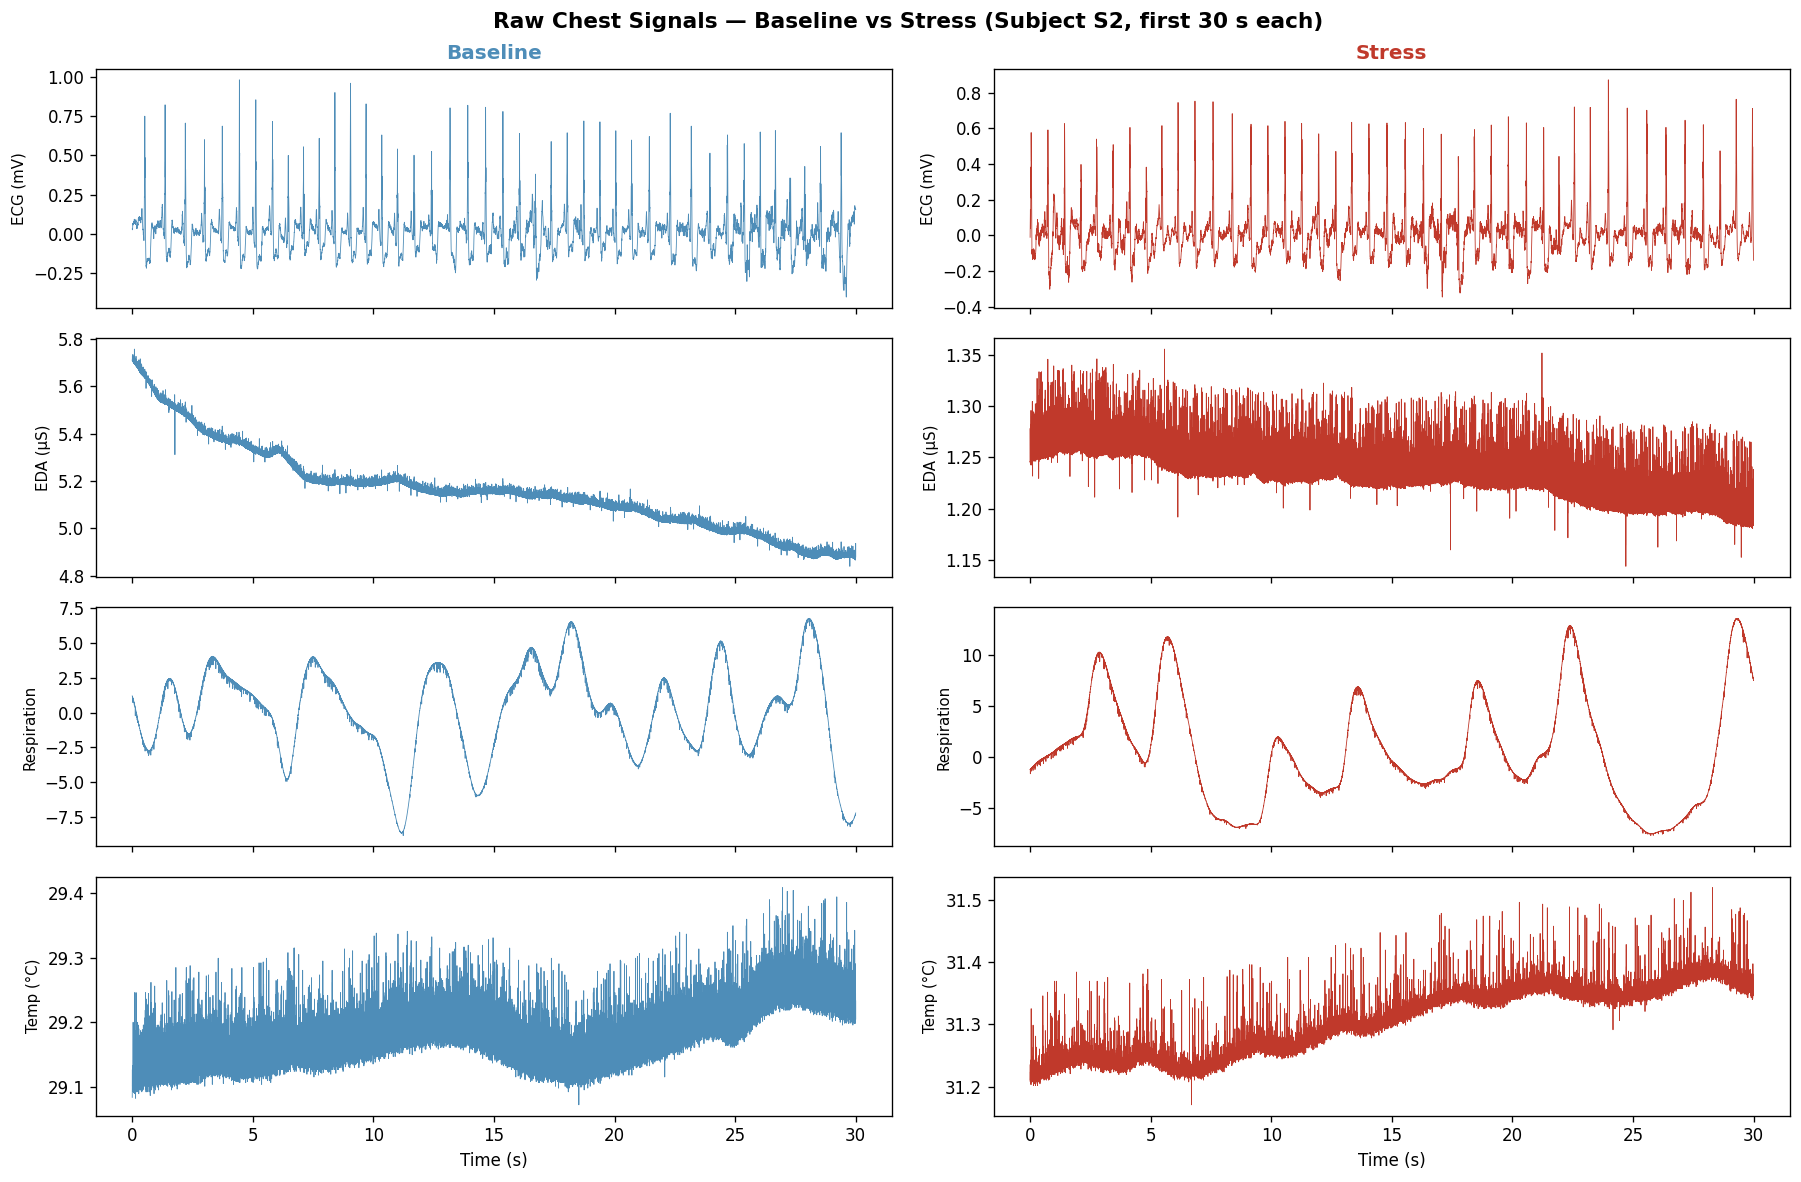

In [3]:
PLOT_SEC  = 30
PLOT_N    = PLOT_SEC * FS_CHEST
MODALITIES = [('ECG', 'ECG (mV)'), ('EDA', 'EDA (μS)'),
              ('Resp', 'Respiration'), ('Temp', 'Temp (°C)')]

d_plot  = load_subject('S2')
labels  = d_plot['label']
chest   = d_plot['signal']['chest']

fig, axes = plt.subplots(4, 2, figsize=(15, 10), sharex='col')
fig.suptitle("Raw Chest Signals — Baseline vs Stress (Subject S2, first 30 s each)",
             fontsize=13, fontweight='bold')

for col, (cond_id, cond_name, color) in enumerate(
        [(1, 'Baseline', '#4e8db8'), (2, 'Stress', '#c0392b')]):
    idx_start = np.where(labels == cond_id)[0][0]
    t = np.arange(PLOT_N) / FS_CHEST

    for row, (mod, ylabel) in enumerate(MODALITIES):
        sig = chest[mod][idx_start : idx_start + PLOT_N].squeeze()
        ax  = axes[row, col]
        ax.plot(t, sig, color=color, linewidth=0.5)
        ax.set_ylabel(ylabel, fontsize=9)
        if row == 0:
            ax.set_title(cond_name, fontsize=12, fontweight='bold', color=color)
        if row == 3:
            ax.set_xlabel('Time (s)')

plt.tight_layout()
plt.savefig('wesad_raw_signals.png', bbox_inches='tight')
plt.show()

## 3 — Feature Extraction

For each 60-second window we extract **18 hand-crafted features**:

| Domain | Features |
|--------|----------|
| **ECG / HRV** | Mean RR interval, SDNN, RMSSD, pNN50, Mean HR |
| **EDA** | Mean, std, min, max, linear slope, SCR peak count |
| **Respiration** | Mean, std, respiratory rate (bpm), rate variability |
| **Temperature** | Mean, std, linear slope |

Features are computed with `scipy` and `neurokit2`. Windows that straddle a condition boundary (< 90% homogeneous label) are discarded to avoid label noise.

In [4]:
def extract_window_features(ecg, eda, resp, temp, fs=FS_CHEST) -> dict:
    """Compute 19 features from one 60-second window of chest signals."""
    feats = {}

    # ── ECG / HRV (time-domain) ───────────────────────────────────────────────
    try:
        _, info  = nk.ecg_process(ecg, sampling_rate=fs)
        r_peaks  = info['ECG_R_Peaks']
        if len(r_peaks) > 3:
            rr_ms = np.diff(r_peaks) / fs * 1000      # ms
            feats['hrv_mean_rr']  = np.mean(rr_ms)
            feats['hrv_sdnn']     = np.std(rr_ms)
            feats['hrv_rmssd']    = np.sqrt(np.mean(np.diff(rr_ms) ** 2))
            feats['hrv_pnn50']    = np.mean(np.abs(np.diff(rr_ms)) > 50) * 100
            feats['hrv_mean_hr']  = 60_000 / np.mean(rr_ms)
        else:
            raise ValueError("too few R-peaks")
    except Exception:
        for k in ['hrv_mean_rr', 'hrv_sdnn', 'hrv_rmssd', 'hrv_pnn50', 'hrv_mean_hr']:
            feats[k] = np.nan

    # ── EDA ───────────────────────────────────────────────────────────────────
    feats['eda_mean']  = np.mean(eda)
    feats['eda_std']   = np.std(eda)
    feats['eda_min']   = np.min(eda)
    feats['eda_max']   = np.max(eda)
    feats['eda_slope'] = stats.linregress(np.arange(len(eda)), eda).slope
    scr_peaks, _       = signal.find_peaks(eda, distance=int(fs * 0.5), prominence=0.01)
    feats['eda_scr_count'] = len(scr_peaks)

    # ── Respiration ───────────────────────────────────────────────────────────
    feats['resp_mean'] = np.mean(resp)
    feats['resp_std']  = np.std(resp)
    try:
        resp_peaks, _ = signal.find_peaks(resp, distance=int(fs * 1.5))
        if len(resp_peaks) > 1:
            cycle_s = np.diff(resp_peaks) / fs
            feats['resp_rate_bpm'] = 60 / np.mean(cycle_s)
            feats['resp_rate_std'] = np.std(60 / cycle_s)
        else:
            raise ValueError("too few breath cycles")
    except Exception:
        feats['resp_rate_bpm'] = np.nan
        feats['resp_rate_std'] = np.nan

    # ── Temperature ───────────────────────────────────────────────────────────
    feats['temp_mean']  = np.mean(temp)
    feats['temp_std']   = np.std(temp)
    feats['temp_slope'] = stats.linregress(np.arange(len(temp)), temp).slope

    return feats


# ── Smoke-test on one window ─────────────────────────────────────────────────
seg_test  = get_segments(load_subject('S2'))
test_feat = extract_window_features(
    seg_test['ECG'][:WINDOW_N], seg_test['EDA'][:WINDOW_N],
    seg_test['Resp'][:WINDOW_N], seg_test['Temp'][:WINDOW_N]
)
print(f"Features per window ({len(test_feat)}):")
for k, v in test_feat.items():
    print(f"  {k:20s}  {v:.4f}")

Features per window (18):
  hrv_mean_rr           742.8036
  hrv_sdnn              95.7943
  hrv_rmssd             65.8849
  hrv_pnn50             24.0506
  hrv_mean_hr           80.7751
  eda_mean              4.9315
  eda_std               0.2716
  eda_min               4.2156
  eda_max               5.7568
  eda_slope             -0.0000
  eda_scr_count         91.0000
  resp_mean             0.0798
  resp_std              2.8228
  resp_rate_bpm         30.0996
  resp_rate_std         6.9317
  temp_mean             29.1566
  temp_std              0.0753
  temp_slope            -0.0000


## 4 — Extract Features from All Subjects

This cell loops over all 15 subjects, slides a 60-second window with no overlap, and discards windows that are not ≥ 90% homogeneous in their label. Results are cached to `wesad_features.csv` so you can re-run the classification cells without re-extracting.

> ⏳ **Expected runtime: ~5–10 minutes** (ECG R-peak detection via neurokit2 is the bottleneck).

In [5]:
CACHE_PATH = "wesad_features.csv"
PURITY_THRESHOLD = 0.90   # minimum label homogeneity to keep a window

def build_feature_dataset(subjects=SUBJECTS, cache=CACHE_PATH) -> pd.DataFrame:
    if os.path.exists(cache):
        print(f"Loading cached features from '{cache}'")
        return pd.read_csv(cache)

    rows = []
    for sub in subjects:
        print(f"  {sub} ...", end=' ', flush=True)
        try:
            seg    = get_segments(load_subject(sub))
            n_win  = len(seg['ECG']) // WINDOW_N
            kept   = 0

            for i in range(n_win):
                s, e         = i * WINDOW_N, (i + 1) * WINDOW_N
                window_lbl   = seg['labels'][s:e]
                stress_frac  = window_lbl.mean()

                # discard mixed windows
                if stress_frac < (1 - PURITY_THRESHOLD) or stress_frac > PURITY_THRESHOLD:
                    label  = int(stress_frac > 0.5)
                    feats  = extract_window_features(
                        seg['ECG'][s:e], seg['EDA'][s:e],
                        seg['Resp'][s:e], seg['Temp'][s:e]
                    )
                    feats['label']   = label
                    feats['subject'] = sub
                    rows.append(feats)
                    kept += 1

            print(f"{kept} windows")
        except Exception as exc:
            print(f"ERROR — {exc}")

    df = pd.DataFrame(rows)
    df.to_csv(cache, index=False)
    print(f"\nSaved to '{cache}'")
    return df


print("Building feature dataset …")
feature_df = build_feature_dataset()

FEAT_COLS = [c for c in feature_df.columns if c not in ('label', 'subject')]
print(f"\nDataset shape  : {feature_df.shape}")
print(f"Feature columns: {len(FEAT_COLS)}")
print(f"Stress windows : {feature_df['label'].sum()}")
print(f"Baseline windows: {(feature_df['label']==0).sum()}")
feature_df.head()

Building feature dataset …
  S2 ... 29 windows
  S3 ... 29 windows
  S4 ... 28 windows
  S5 ... 30 windows
  S6 ... 29 windows
  S7 ... 29 windows
  S8 ... 29 windows
  S9 ... 29 windows
  S10 ... 30 windows
  S11 ... 30 windows
  S13 ... 29 windows
  S14 ... 29 windows
  S15 ... 30 windows
  S16 ... 29 windows
  S17 ... 30 windows

Saved to 'wesad_features.csv'

Dataset shape  : (439, 20)
Feature columns: 18
Stress windows : 153
Baseline windows: 286


,hrv_mean_rr,hrv_sdnn,hrv_rmssd,hrv_pnn50,hrv_mean_hr,eda_mean,eda_std,eda_min,eda_max,eda_slope,eda_scr_count,resp_mean,resp_std,resp_rate_bpm,resp_rate_std,temp_mean,temp_std,temp_slope,label,subject
0,742.803571,95.794328,65.884872,24.050633,80.775056,4.931493,0.271649,4.215622,5.756760,-0.000022,91,0.079788,2.822798,30.099615,6.931705,29.156557,0.075281,-2.710003e-06,0,S2
1,845.279503,74.067327,52.367996,27.941176,70.982438,4.104213,0.220188,3.721619,4.565048,-0.000018,86,0.048580,1.587338,26.587456,6.959020,28.858253,0.072988,-5.446433e-06,0,S2
2,802.230920,74.563678,63.268630,33.333333,74.791433,3.497977,0.146025,3.255463,3.850174,-0.000011,86,0.054605,1.902464,23.438637,2.324992,28.803823,0.038005,9.401081e-08,0,S2
3,829.183673,50.652058,52.001638,33.333333,72.360325,3.023401,0.155224,2.636337,3.388977,-0.000013,90,0.044015,1.464835,26.076989,6.357983,28.732267,0.069768,-4.617014e-06,0,S2
4,824.366197,58.858006,51.702220,28.571429,72.783188,2.583080,0.104606,2.121353,2.835083,-0.000009,89,0.062353,1.447229,25.554285,6.399065,28.572529,0.039667,1.178216e-06,0,S2


## 5 — Leave-One-Subject-Out (LOSO) Classification

We use **LOSO cross-validation**: in each fold, one subject is held out as the test set and the model is trained on the remaining 14. This mimics a real deployment scenario where the model must generalize to a new, unseen person.

**Model:** Random Forest (100 trees, balanced class weights)  
**Pre-processing:** NaN imputation with training-set column means, followed by StandardScaler normalization.

In [6]:
def impute_with_train_means(X_train, X_test):
    """Replace NaNs in test set using per-feature means computed from training set."""
    col_means = np.nanmean(X_train, axis=0)
    for j in range(X_train.shape[1]):
        X_train[np.isnan(X_train[:, j]), j] = col_means[j]
        X_test[np.isnan(X_test[:, j]),  j] = col_means[j]
    return X_train, X_test


loso_results = []
all_y_true, all_y_pred, all_y_prob = [], [], []

present_subs = feature_df['subject'].unique()

for test_sub in present_subs:
    train_df = feature_df[feature_df['subject'] != test_sub]
    test_df  = feature_df[feature_df['subject'] == test_sub]

    if len(test_df) == 0 or test_df['label'].nunique() < 2:
        continue

    X_tr = train_df[FEAT_COLS].values.copy()
    y_tr = train_df['label'].values
    X_te = test_df[FEAT_COLS].values.copy()
    y_te = test_df['label'].values

    X_tr, X_te = impute_with_train_means(X_tr, X_te)

    scaler = StandardScaler()
    X_tr   = scaler.fit_transform(X_tr)
    X_te   = scaler.transform(X_te)

    clf = RandomForestClassifier(n_estimators=100, random_state=42,
                                  class_weight='balanced', n_jobs=-1)
    clf.fit(X_tr, y_tr)

    y_pred = clf.predict(X_te)
    y_prob = clf.predict_proba(X_te)[:, 1]

    acc = accuracy_score(y_te, y_pred)
    f1  = f1_score(y_te, y_pred, zero_division=0)
    auc = roc_auc_score(y_te, y_prob)

    loso_results.append({'subject': test_sub, 'accuracy': acc, 'f1': f1, 'auc': auc})
    all_y_true.extend(y_te)
    all_y_pred.extend(y_pred)
    all_y_prob.extend(y_prob)

    print(f"{test_sub}  |  Acc={acc:.3f}  F1={f1:.3f}  AUC={auc:.3f}")

results_df = pd.DataFrame(loso_results)
print("\n─── LOSO Summary ──────────────────────────────────")
for metric in ['accuracy', 'f1', 'auc']:
    m, s = results_df[metric].mean(), results_df[metric].std()
    print(f"  {metric.capitalize():10s}: {m:.3f} ± {s:.3f}")

S2  |  Acc=0.724  F1=0.429  AUC=0.818
S3  |  Acc=0.897  F1=0.824  AUC=1.000
S4  |  Acc=1.000  F1=1.000  AUC=1.000
S5  |  Acc=1.000  F1=1.000  AUC=1.000
S6  |  Acc=1.000  F1=1.000  AUC=1.000
S7  |  Acc=0.931  F1=0.900  AUC=0.968
S8  |  Acc=1.000  F1=1.000  AUC=1.000
S9  |  Acc=0.897  F1=0.857  AUC=0.974
S10  |  Acc=0.700  F1=0.308  AUC=0.522
S11  |  Acc=0.900  F1=0.880  AUC=1.000
S13  |  Acc=0.966  F1=0.952  AUC=1.000
S14  |  Acc=1.000  F1=1.000  AUC=1.000
S15  |  Acc=0.967  F1=0.952  AUC=0.964
S16  |  Acc=1.000  F1=1.000  AUC=1.000
S17  |  Acc=0.933  F1=0.917  AUC=0.986

─── LOSO Summary ──────────────────────────────────
  Accuracy  : 0.928 ± 0.096
  F1        : 0.868 ± 0.212
  Auc       : 0.949 ± 0.127


## 6 — Results Visualization

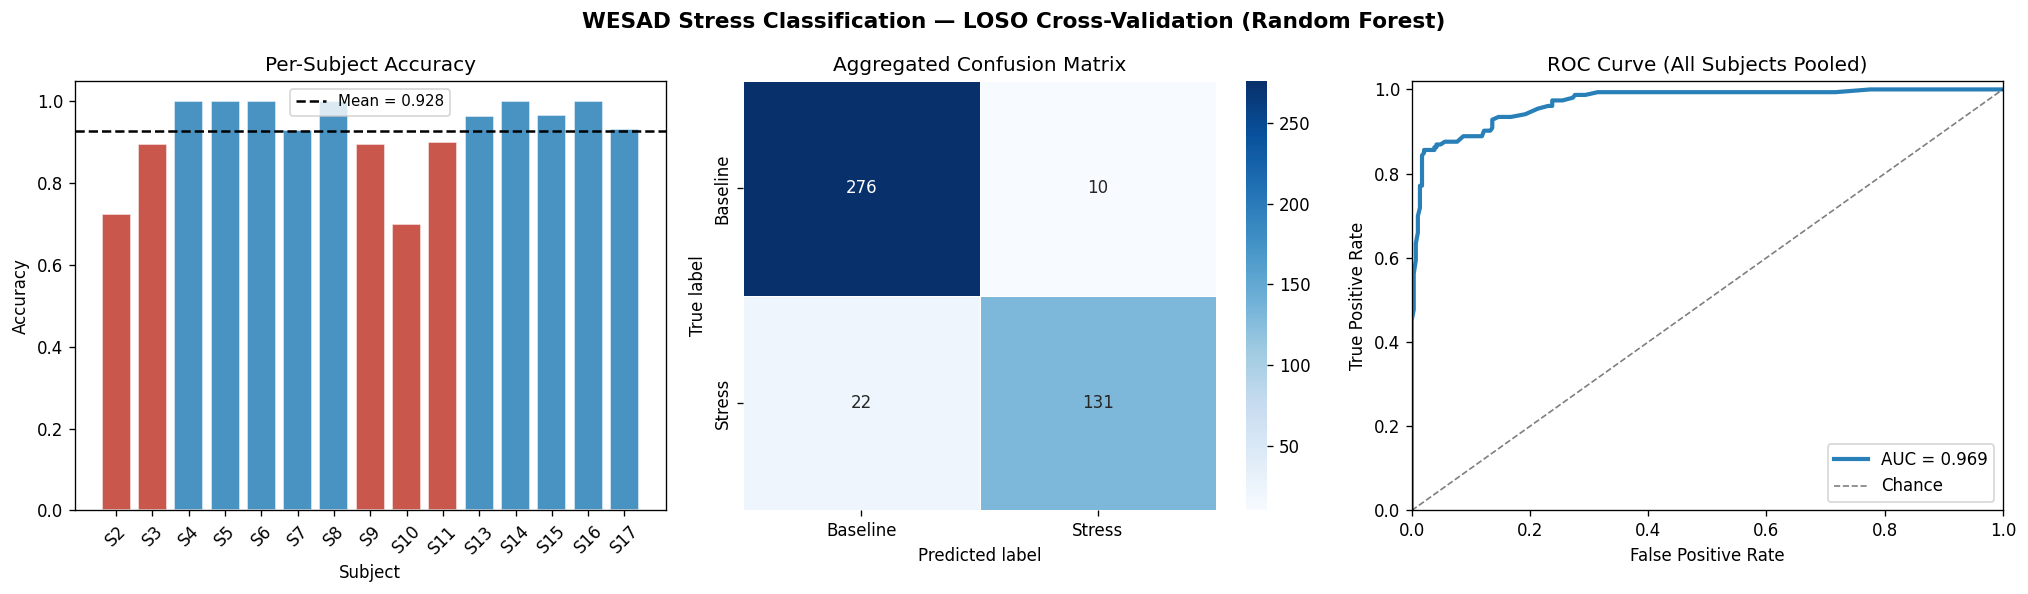

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("WESAD Stress Classification — LOSO Cross-Validation (Random Forest)",
             fontsize=13, fontweight='bold')

# ── A: Per-subject accuracy ───────────────────────────────────────────────────
ax = axes[0]
mean_acc = results_df['accuracy'].mean()
bar_colors = ['#c0392b' if a < mean_acc else '#2980b9'
              for a in results_df['accuracy']]
ax.bar(results_df['subject'], results_df['accuracy'],
       color=bar_colors, alpha=0.85, edgecolor='white')
ax.axhline(mean_acc, color='black', linestyle='--', linewidth=1.5,
           label=f"Mean = {mean_acc:.3f}")
ax.set_ylim(0, 1.05)
ax.set_xlabel('Subject')
ax.set_ylabel('Accuracy')
ax.set_title('Per-Subject Accuracy')
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=9)

# ── B: Aggregated confusion matrix ───────────────────────────────────────────
ax = axes[1]
cm = confusion_matrix(all_y_true, all_y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, linewidths=0.5,
            xticklabels=['Baseline', 'Stress'],
            yticklabels=['Baseline', 'Stress'])
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title('Aggregated Confusion Matrix')

# ── C: ROC curve ─────────────────────────────────────────────────────────────
ax = axes[2]
fpr, tpr, _ = roc_curve(all_y_true, all_y_prob)
overall_auc = roc_auc_score(all_y_true, all_y_prob)
ax.plot(fpr, tpr, color='#2980b9', linewidth=2.5, label=f"AUC = {overall_auc:.3f}")
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Chance')
ax.set_xlim([0, 1]);  ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve (All Subjects Pooled)')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('wesad_results.png', bbox_inches='tight')
plt.show()

## 7 — Feature Importance

Train a final Random Forest on the full dataset (all subjects) to rank features. This does **not** represent generalization performance — it shows which signals the model relies on most when given all available data.

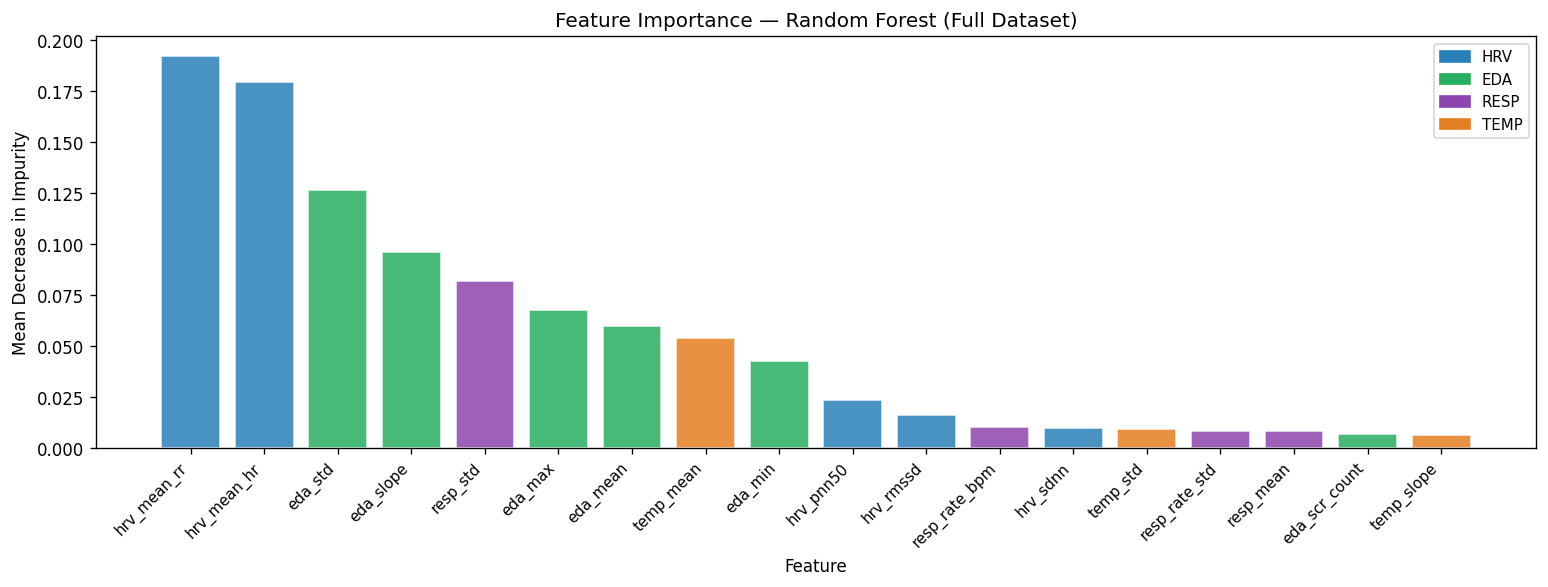

Top 5 features:
  1. hrv_mean_rr             0.1925
  2. hrv_mean_hr             0.1795
  3. eda_std                 0.1263
  4. eda_slope               0.0962
  5. resp_std                0.0818


In [8]:
X_all = feature_df[FEAT_COLS].copy()
X_all = X_all.fillna(X_all.mean())
y_all = feature_df['label'].values

scaler_full = StandardScaler()
X_all_sc    = scaler_full.fit_transform(X_all)

clf_full = RandomForestClassifier(n_estimators=200, random_state=42,
                                   class_weight='balanced', n_jobs=-1)
clf_full.fit(X_all_sc, y_all)

importances = clf_full.feature_importances_
order       = np.argsort(importances)[::-1]

# ── Color bars by modality ────────────────────────────────────────────────────
MODALITY_COLORS = {
    'hrv': '#2980b9',
    'eda': '#27ae60',
    'resp': '#8e44ad',
    'temp': '#e67e22',
}

def feat_color(name):
    for prefix, color in MODALITY_COLORS.items():
        if name.startswith(prefix):
            return color
    return 'gray'

fig, ax = plt.subplots(figsize=(13, 5))
bar_cols = [feat_color(FEAT_COLS[i]) for i in order]
ax.bar(range(len(FEAT_COLS)), importances[order], color=bar_cols, alpha=0.85, edgecolor='white')
ax.set_xticks(range(len(FEAT_COLS)))
ax.set_xticklabels([FEAT_COLS[i] for i in order], rotation=45, ha='right', fontsize=9)
ax.set_xlabel('Feature')
ax.set_ylabel('Mean Decrease in Impurity')
ax.set_title('Feature Importance — Random Forest (Full Dataset)', fontsize=12)

# Legend
from matplotlib.patches import Patch
legend_items = [Patch(color=c, label=m.upper()) for m, c in MODALITY_COLORS.items()]
ax.legend(handles=legend_items, fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig('wesad_feature_importance.png', bbox_inches='tight')
plt.show()

print("Top 5 features:")
for rank, i in enumerate(order[:5], 1):
    print(f"  {rank}. {FEAT_COLS[i]:22s}  {importances[i]:.4f}")